# Load Titanic dataset
# NOTE: Make sure titanic.csv exists at this path or update the path accordingly.
# You can download from here.  https://www.kaggle.com/datasets/yasserh/titanic-dataset

In [52]:
import pandas as pd
titanic_path='/content/sample_data/Titanic-Dataset.csv'
df_t=pd.read_csv(titanic_path)
df_t.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [53]:
df_t.shape

(891, 12)

In [54]:
df_t.nunique()

,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


In [55]:
#missing
df_t.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


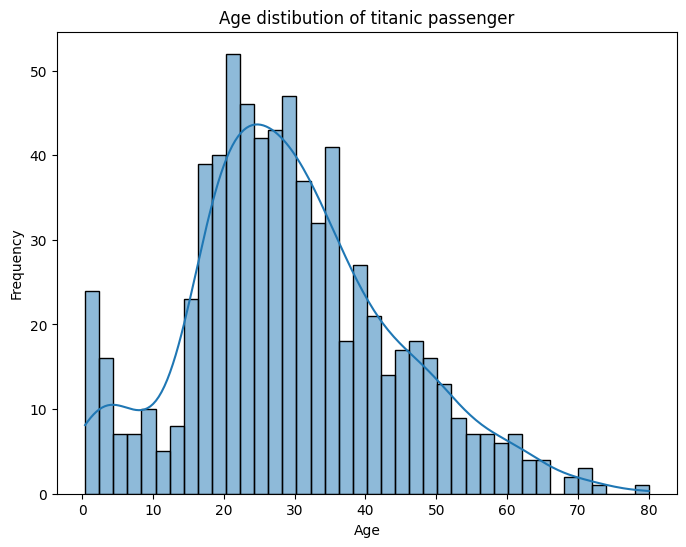

In [56]:
#distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.histplot(df_t['Age'], kde=True, bins=40)
plt.title('Age distibution of titanic passenger')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [57]:
# we will use median as the feature are right skewed

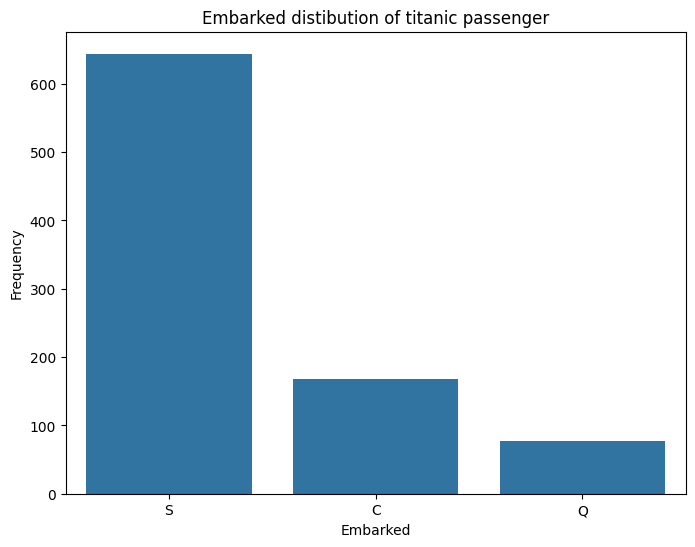

In [58]:
plt.figure(figsize=(8,6))
sns.countplot(data=df_t,x='Embarked')
plt.title('Embarked distibution of titanic passenger')
plt.xlabel('Embarked')
plt.ylabel('Frequency')
plt.show()

#use mode for mission valaue


In [59]:
#handle numeric missing values :Age
age_meidan=df_t['Age'].median()
df_t['Age']=df_t['Age'].fillna(age_meidan)

#handle categorical mission value :Embarked
Embarked_mode=df_t['Embarked'].mode()[0]
df_t['Embarked']=df_t['Embarked'].fillna(Embarked_mode)

#deom cabin(too mission many value)
df_t=df_t.drop(columns=['Cabin'])

In [60]:
df_t.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


###Encoding Categorical Variables (Heart Dataset)

In [61]:
from sklearn.preprocessing import LabelEncoder

# Load Heart dataset
heart_path = "/content/sample_data/heart.csv"  # change if needed
df_heart= pd.read_csv(heart_path)

print("First 10 rows of Heart dataset:")
display(df_heart.head(10))

print("\nColumn data types:")
display(df_heart.dtypes)

First 10 rows of Heart dataset:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0



Column data types:


,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


In [62]:
target_Col='HeartDisease'
numeric_col=['Age','RestingBP','Cholesterol','FastingBS','MaxHR','Oldpeak']  #,'HeartDisease'
categorical_cols=['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope']

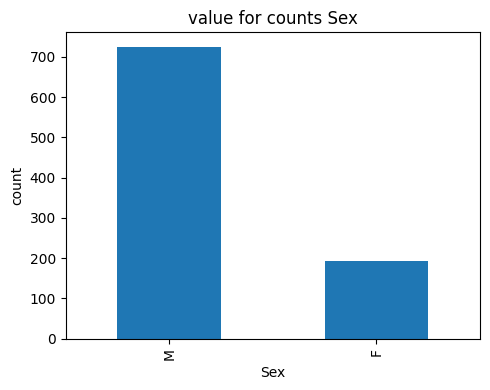

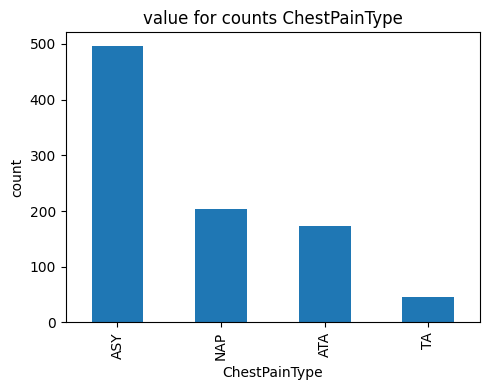

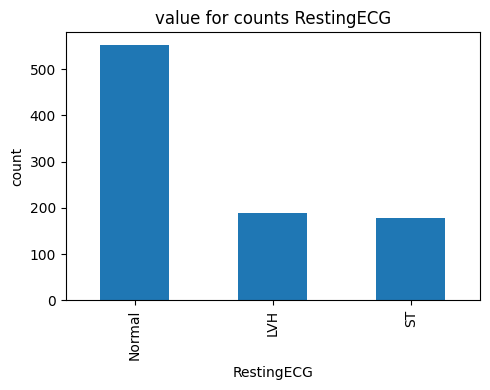

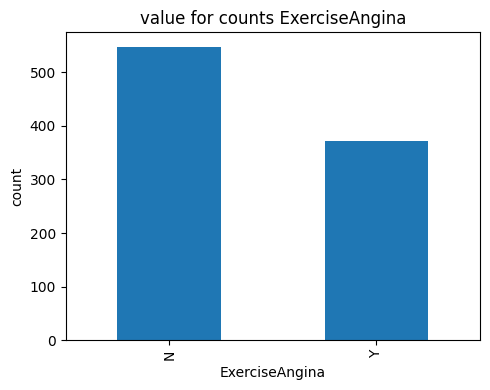

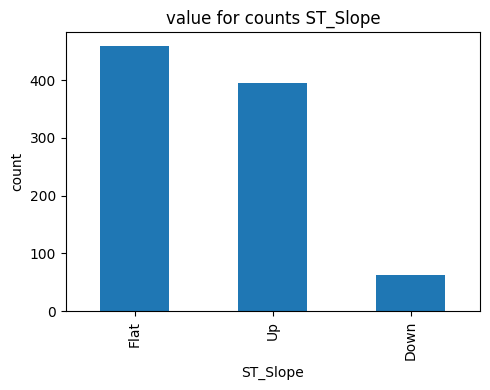

In [63]:
for c in categorical_cols:
  plt.figure(figsize=(5,4))
  df_heart[c].value_counts().plot(kind='bar')
  plt.title(f'value for counts {c}')
  plt.ylabel('count')
  plt.tight_layout()
  plt.show()

In [64]:
#label encoding for binary categorical columns
le=LabelEncoder()
df_heart['Sex']=le.fit_transform(df['Sex'])
df_heart['ExerciseAngina']=le.fit_transform(df['ExerciseAngina'])

In [65]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289,0,Normal,172,0,0.0,Up,0
1,49,0,NAP,160,180,0,Normal,156,0,1.0,Flat,1
2,37,1,ATA,130,283,0,ST,98,0,0.0,Up,0
3,48,0,ASY,138,214,0,Normal,108,1,1.5,Flat,1
4,54,1,NAP,150,195,0,Normal,122,0,0.0,Up,0


In [66]:
#onehot encoding for nominal categorical  columns
cat_cols=['ChestPainType','RestingECG','ST_Slope']
df_heart_encoding=pd.get_dummies(
    df_heart,
    columns=cat_cols,
    dtype=int
)

In [67]:
df_heart_encoding.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,0,1,0,0,0,1,0,0,0,1
1,49,0,160,180,0,156,0,1.0,1,0,0,1,0,0,1,0,0,1,0
2,37,1,130,283,0,98,0,0.0,0,0,1,0,0,0,0,1,0,0,1
3,48,0,138,214,0,108,1,1.5,1,1,0,0,0,0,1,0,0,1,0
4,54,1,150,195,0,122,0,0.0,0,0,0,1,0,0,1,0,0,0,1


#normalizing and scaling

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

#assume df_heart_enconfding
target_Col='HeartDisease'

x=df_heart_encoding.drop(columns=[target_Col])
y=df_heart_encoding[target_Col]

x_train,x_test, y_train,y_test=train_test_split(x,y, test_size=.25, random_state=42)

#standard scaling
scaler_sd= StandardScaler()
x_train_std=scaler_sd.fit_transform(x_train) #mean ans sd will be calculate from x_train
x_test_std=scaler_sd.transform(x_test)

#minmax scaling
scaler_mm=MinMaxScaler()
x_train_mm=scaler_mm.fit_transform(x_train)
x_test_mm=scaler_mm.fit_transform(x_test)

print('\n ---Displayinng standard scaled data--')

#convet scaled arrays back to dataframse for batte visulalization with colums names
x_train_std_df=pd.DataFrame(x_train_std, columns=x_train.columns, index=x_train.index)
x_test_std_df=pd.DataFrame(x_test_std, columns=x_test.columns, index=x_test.index)
print('\n ---first 5 rows of x_train ans x_test(standard scaled--')
display(x_train_std_df.head())
display(x_test_std_df.head())

print('\n ---first 5 rows of x_train (minmax scaled)--')
#convet scaled arrays back to dataframse for batte visulalization with colums names
x_train_mm_df=pd.DataFrame(x_train_mm, columns=x_train.columns, index=x_train.index)
x_test_mm_df=pd.DataFrame(x_test_mm, columns=x_test.columns, index=x_test.index)
print('\n ---Displayinng --')
display(x_train_mm_df.head())
display(x_test_mm_df.head())


 ---Displayinng standard scaled data--

 ---first 5 rows of x_train ans x_test(standard scaled--


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
155,0.239292,0.537019,1.183802,1.307314,1.877849,0.551672,1.182037,1.900458,0.905597,-0.480384,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,0.962897,-0.851064
362,0.239292,0.537019,1.183802,-1.878000,-0.532524,-1.486343,-0.845997,-0.834739,-1.104244,-0.480384,1.885813,-0.213524,-0.505445,-1.225487,2.023931,-0.254981,0.962897,-0.851064
869,0.558968,0.537019,0.913811,0.096522,1.877849,0.831400,-0.845997,0.624033,-1.104244,-0.480384,1.885813,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999
101,-0.293501,0.537019,-0.166155,-0.210833,-0.532524,-1.446382,-0.845997,-0.834739,0.905597,-0.480384,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999
199,0.345851,-1.862131,-0.166155,0.990645,-0.532524,-1.526304,-0.845997,0.076994,-1.104244,-0.480384,-0.530275,4.683304,-0.505445,0.816002,-0.494088,-0.254981,0.962897,-0.851064


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
668,0.985202,-1.862131,0.373828,-0.061812,-0.532524,1.710544,-0.845997,-0.834739,-1.104244,2.081666,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999
30,-0.080384,0.537019,0.643819,2.946539,-0.532524,-0.247550,-0.845997,-0.834739,-1.104244,-0.480384,1.885813,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,0.962897,-0.851064
377,1.198319,0.537019,1.453793,-1.878000,1.877849,-0.567238,-0.845997,0.259340,0.905597,-0.480384,-0.530275,-0.213524,-0.505445,-1.225487,2.023931,-0.254981,0.962897,-0.851064
535,0.239292,0.537019,-0.166155,-1.878000,-0.532524,-0.567238,1.182037,0.076994,0.905597,-0.480384,-0.530275,-0.213524,1.978455,-1.225487,-0.494088,-0.254981,0.962897,-0.851064
807,0.026175,0.537019,-1.354116,0.999959,-0.532524,0.791439,-0.845997,-0.834739,-1.104244,2.081666,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999



 ---first 5 rows of x_train (minmax scaled)--

 ---Displayinng --


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
155,0.562500,1.0,0.775,0.567164,1.0,0.674419,1.0,0.636364,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
362,0.562500,1.0,0.775,0.000000,0.0,0.279070,0.0,0.295455,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
869,0.625000,1.0,0.750,0.351575,1.0,0.728682,0.0,0.477273,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
101,0.458333,1.0,0.650,0.296849,0.0,0.286822,0.0,0.295455,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
199,0.583333,0.0,0.650,0.510779,0.0,0.271318,0.0,0.409091,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
668,0.729167,0.0,0.500000,0.345745,0.0,0.838028,0.0,0.215686,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
30,0.520833,1.0,0.541667,0.918440,0.0,0.492958,0.0,0.215686,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
377,0.770833,1.0,0.666667,0.000000,1.0,0.436620,0.0,0.450980,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
535,0.583333,1.0,0.416667,0.000000,0.0,0.436620,1.0,0.411765,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
807,0.541667,1.0,0.233333,0.547872,0.0,0.676056,0.0,0.215686,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
